In [1]:
# load libraies

%run py_libraries.py

/Users/4476224/.local/lib/python3.8/site-packages/tensorflow_addons/utils/ensure_tf_install.py:53: UserWarning: Tensorflow Addons supports using Python ops for all Tensorflow versions above or equal to 2.6.0 and strictly below 2.9.0 (nightly versions are not supported). 
 The versions of TensorFlow you are currently using is 2.13.0 and is not supported. 
Some things might work, some things might not.
If you were to encounter a bug, do not file an issue.
If you want to make sure you're using a tested and supported configuration, either change the TensorFlow version or the TensorFlow Addons's version. 
You can find the compatibility matrix in TensorFlow Addon's readme:
https://github.com/tensorflow/addons
  warnings.warn(


Instructions for updating:
non-resource variables are not supported in the long term


In [2]:
# loading utility files

from utility.sv_fig import savefig

In [3]:
pd.set_option('display.max_columns', None)
pd.set_option('display.max_row', None)

# load data
X_train = pd.read_csv('data/norm_X_train_Yes_No.csv')
X_test = pd.read_csv('data/norm_X_test_Yes_No.csv')
y_train = pd.read_csv('data/y_train_Yes_No.csv')
y_test = pd.read_csv('data/y_test_Yes_No.csv')


# print(X_train.shape)

In [4]:
# Boxplot for training data, testing data, ext validation data


bx_trn = pd.concat([X_train,y_train], axis=1)
bx_tst = pd.concat([X_test,y_test], axis=1)

bx_trn['OverallTILGrowth'] = bx_trn['OverallTILGrowth'].replace(to_replace=1.0,value="Yes TIL")
bx_trn['OverallTILGrowth'] = bx_trn['OverallTILGrowth'].replace(to_replace=0.0,value="No TIL")

bx_tst['OverallTILGrowth'] = bx_tst['OverallTILGrowth'].replace(to_replace=1.0,value="Yes TIL")
bx_tst['OverallTILGrowth'] = bx_tst['OverallTILGrowth'].replace(to_replace=0.0,value="No TIL")


# print(bx_trn)
# print(bx_tst)

In [5]:
print(bx_trn.shape)
print(bx_tst.shape)

(74, 16)
(32, 16)


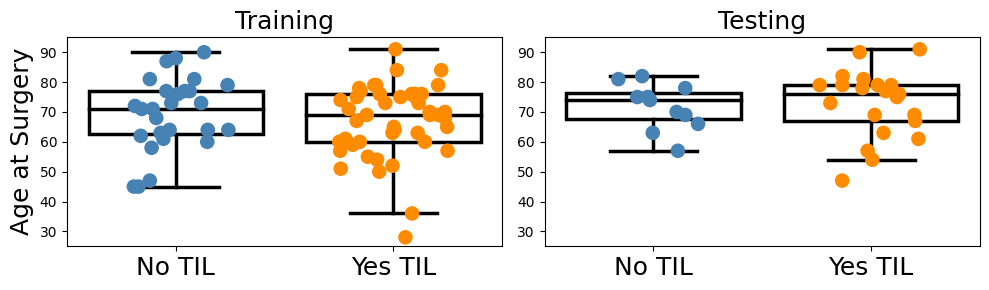

In [6]:


f, axes = plt.subplots(1, 2, figsize=(10, 3))

PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'k'},
    'medianprops':{'color':'k'},
    'whiskerprops':{'color':'k'},
    'capprops':{'color':'k'}
}

g0=sns.boxplot(x='OverallTILGrowth',y="Age_at_Surgery" ,data=bx_trn, ax=axes[0],order=['No TIL','Yes TIL'],\
               showfliers=False, linewidth=2.5, **PROPS)
sns.stripplot(data=bx_trn, x="OverallTILGrowth", y="Age_at_Surgery",hue="OverallTILGrowth",order=['No TIL','Yes TIL'],\
              palette={"Yes TIL": "darkorange", "No TIL": "steelblue"}, legend=False, ax=axes[0],jitter=0.25, s=10.5)
g0.set_ylabel('Age at Surgery', fontdict={'size': 18})
g0.set_ylim(25,95)
g0.set(xlabel=None)
g0.set_title('Training', fontdict={'size': 18})
# For Training plot
g0.set_xticklabels(g0.get_xticklabels(), fontsize=18)



g1=sns.boxplot(x='OverallTILGrowth',y="Age_at_Surgery" ,data=bx_tst, ax=axes[1],order=['No TIL','Yes TIL'],\
               showfliers=False, linewidth=2.5, **PROPS)
sns.stripplot(data=bx_tst, x="OverallTILGrowth", y="Age_at_Surgery",hue="OverallTILGrowth",order=['No TIL','Yes TIL'],\
              palette={"Yes TIL": "darkorange", "No TIL": "steelblue"}, legend=False, ax=axes[1],jitter=0.25, s=10.5)
g1.set_ylim(25,95)
g1.set(xlabel=None)
g1.set(ylabel=None)
g1.set_title('Testing', fontdict={'size': 18})
# For Testing plot
g1.set_xticklabels(g1.get_xticklabels(), fontsize=18)

f.tight_layout()

savefig('./figs/Age_at_Surgery')
# plt.show()



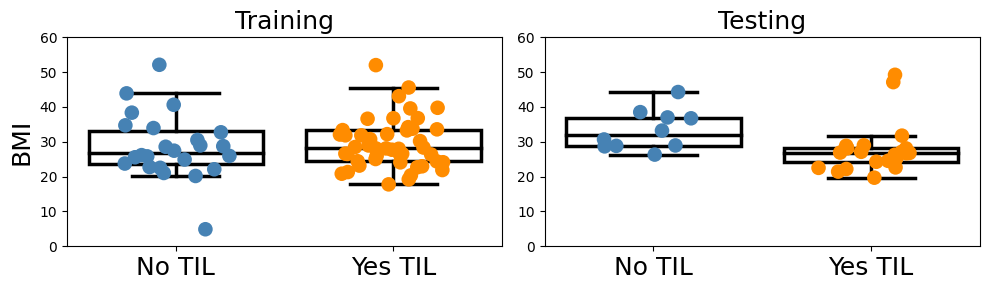

In [7]:


f, axes = plt.subplots(1, 2, figsize=(10, 3))

PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'k'},
    'medianprops':{'color':'k'},
    'whiskerprops':{'color':'k'},
    'capprops':{'color':'k'}
}

g0=sns.boxplot(x='OverallTILGrowth',y="BMI" ,data=bx_trn, ax=axes[0],order=['No TIL','Yes TIL'],\
               showfliers=False, linewidth=2.5, **PROPS)
sns.stripplot(data=bx_trn, x="OverallTILGrowth", y="BMI",hue="OverallTILGrowth",order=['No TIL','Yes TIL'],\
              palette={"Yes TIL": "darkorange", "No TIL": "steelblue"}, legend=False, ax=axes[0],jitter=0.25, s=10.5)
g0.set_ylabel('BMI', fontdict={'size': 18})
g0.set_ylim(0,60)
g0.set(xlabel=None)
g0.set_title('Training', fontdict={'size': 18})
# For Training plot
g0.set_xticklabels(g0.get_xticklabels(), fontsize=18)


g1=sns.boxplot(x='OverallTILGrowth',y="BMI" ,data=bx_tst, ax=axes[1],order=['No TIL','Yes TIL'],\
               showfliers=False, linewidth=2.5, **PROPS)
sns.stripplot(data=bx_tst, x="OverallTILGrowth", y="BMI",hue="OverallTILGrowth",order=['No TIL','Yes TIL'],\
              palette={"Yes TIL": "darkorange", "No TIL": "steelblue"}, legend=False, ax=axes[1],jitter=0.25, s=10.5)
g1.set_ylim(0,60)
g1.set(xlabel=None)
g1.set(ylabel=None)
g1.set_title('Testing', fontdict={'size': 18})
# For Testing plot
g1.set_xticklabels(g1.get_xticklabels(), fontsize=18)


f.tight_layout()

savefig('./figs/BMI')
# plt.show()



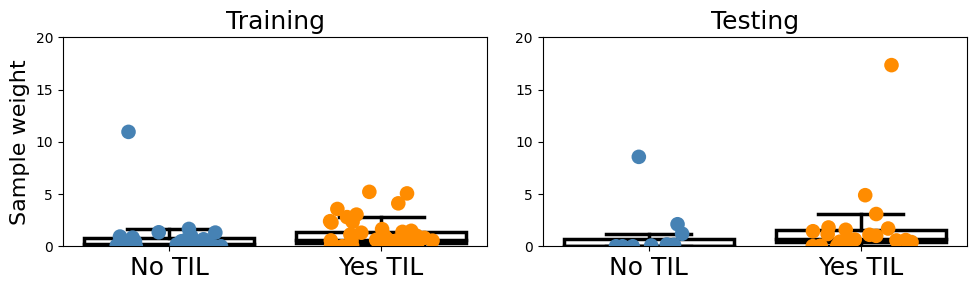

In [8]:


f, axes = plt.subplots(1, 2, figsize=(10, 3))

PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'k'},
    'medianprops':{'color':'k'},
    'whiskerprops':{'color':'k'},
    'capprops':{'color':'k'}
}

g0=sns.boxplot(x='OverallTILGrowth',y="Sample_weight" ,data=bx_trn, ax=axes[0],order=['No TIL','Yes TIL'],\
               showfliers=False, linewidth=2.5, **PROPS)
sns.stripplot(data=bx_trn, x="OverallTILGrowth", y="Sample_weight",hue="OverallTILGrowth",order=['No TIL','Yes TIL'],\
              palette={"Yes TIL": "darkorange", "No TIL": "steelblue"}, legend=False, ax=axes[0],jitter=0.25, s=10.5)
g0.set_ylabel('Sample weight', fontdict={'size': 16})
g0.set_ylim(0,20)
g0.set(xlabel=None)
g0.set_title('Training', fontdict={'size': 18})
# For Training plot
g0.set_xticklabels(g0.get_xticklabels(), fontsize=18)


g1=sns.boxplot(x='OverallTILGrowth',y="Sample_weight" ,data=bx_tst, ax=axes[1],order=['No TIL','Yes TIL'],\
               showfliers=False, linewidth=2.5, **PROPS)
sns.stripplot(data=bx_tst, x="OverallTILGrowth", y="Sample_weight",hue="OverallTILGrowth",order=['No TIL','Yes TIL'],\
              palette={"Yes TIL": "darkorange", "No TIL": "steelblue"}, legend=False, ax=axes[1],jitter=0.25, s=10.5)
g1.set_ylim(0,20)
g1.set(xlabel=None)
g1.set(ylabel=None)
g1.set_title('Testing', fontdict={'size': 18})
# For Testing plot
g1.set_xticklabels(g1.get_xticklabels(), fontsize=18)


f.tight_layout()

savefig('./figs/Sample_weight')
# plt.show()


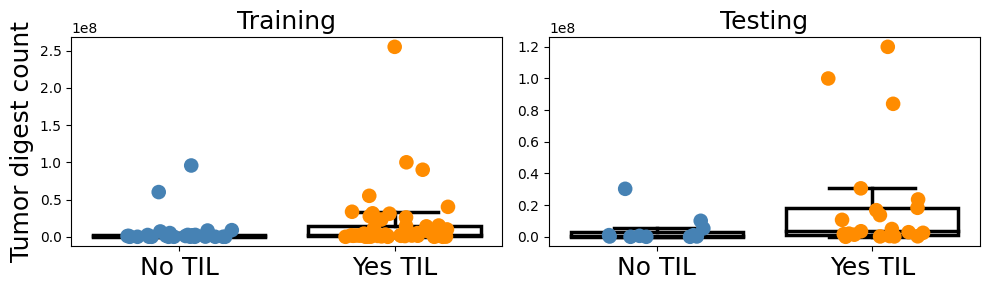

In [9]:


f, axes = plt.subplots(1, 2, figsize=(10, 3))

PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'k'},
    'medianprops':{'color':'k'},
    'whiskerprops':{'color':'k'},
    'capprops':{'color':'k'}
}

g0=sns.boxplot(x='OverallTILGrowth',y="Tumor_digest_count" ,data=bx_trn, ax=axes[0],order=['No TIL','Yes TIL'],\
               showfliers=False, linewidth=2.5, **PROPS)
sns.stripplot(data=bx_trn, x="OverallTILGrowth", y="Tumor_digest_count",hue="OverallTILGrowth",order=['No TIL','Yes TIL'],\
              palette={"Yes TIL": "darkorange", "No TIL": "steelblue"}, legend=False, ax=axes[0],jitter=0.25, s=10.5)
g0.set_ylabel('Tumor digest count', fontdict={'size': 18})
#g0.set_ylim(0,2.5*10**8)
g0.set(xlabel=None)
g0.set_title('Training', fontdict={'size': 18})
# For Training plot
g0.set_xticklabels(g0.get_xticklabels(), fontsize=18)


g1=sns.boxplot(x='OverallTILGrowth',y="Tumor_digest_count" ,data=bx_tst, ax=axes[1],order=['No TIL','Yes TIL'],\
               showfliers=False, linewidth=2.5, **PROPS)
sns.stripplot(data=bx_tst, x="OverallTILGrowth", y="Tumor_digest_count",hue="OverallTILGrowth",order=['No TIL','Yes TIL'],\
              palette={"Yes TIL": "darkorange", "No TIL": "steelblue"}, legend=False, ax=axes[1],jitter=0.25, s=10.5)
#g1.set_ylim(0,2.5*10**8)
g1.set(xlabel=None)
g1.set(ylabel=None)
g1.set_title('Testing', fontdict={'size': 18})
# For Testing plot
g1.set_xticklabels(g1.get_xticklabels(), fontsize=18)


f.tight_layout()

savefig('./figs/Tumor_digest_count')
# plt.show()



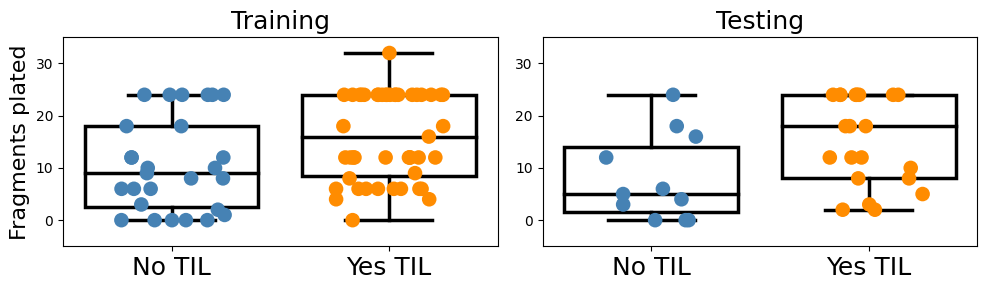

In [10]:


f, axes = plt.subplots(1, 2, figsize=(10, 3))

PROPS = {
    'boxprops':{'facecolor':'none', 'edgecolor':'k'},
    'medianprops':{'color':'k'},
    'whiskerprops':{'color':'k'},
    'capprops':{'color':'k'}
}

g0=sns.boxplot(x='OverallTILGrowth',y="Fragments_plated" ,data=bx_trn, ax=axes[0],order=['No TIL','Yes TIL'],\
               showfliers=False, linewidth=2.5, **PROPS)
sns.stripplot(data=bx_trn, x="OverallTILGrowth", y="Fragments_plated",hue="OverallTILGrowth",order=['No TIL','Yes TIL'],\
              palette={"Yes TIL": "darkorange", "No TIL": "steelblue"}, legend=False, ax=axes[0],jitter=0.25, s=10.5)
g0.set_ylabel('Fragments plated', fontdict={'size': 16})
g0.set_ylim(-5,35)
g0.set(xlabel=None)
g0.set_title('Training', fontdict={'size': 18})
# For Training plot
g0.set_xticklabels(g0.get_xticklabels(), fontsize=18)


g1=sns.boxplot(x='OverallTILGrowth',y="Fragments_plated" ,data=bx_tst, ax=axes[1],order=['No TIL','Yes TIL'],\
               showfliers=False, linewidth=2.5, **PROPS)
sns.stripplot(data=bx_tst, x="OverallTILGrowth", y="Fragments_plated",hue="OverallTILGrowth",order=['No TIL','Yes TIL'],\
              palette={"Yes TIL": "darkorange", "No TIL": "steelblue"}, legend=False, ax=axes[1],jitter=0.25, s=10.5)
g1.set_ylim(-5,35)
g1.set(xlabel=None)
g1.set(ylabel=None)
g1.set_title('Testing', fontdict={'size': 18})
# For Testing plot
g1.set_xticklabels(g1.get_xticklabels(), fontsize=18)


f.tight_layout()

savefig('./figs/Fragments_plated')
# plt.show()

